
Co_R1s(r) =
-267.2101 * exp(-26.8321 r)
-8.3596 * exp(-44.2707 r)
-87.8990 * r * exp(-22.9314 r)
-3.2199 * r * exp(-12.1136 r)
+8.1898 * r^2 * exp(-11.3118 r)
-1.4791 * r^2 * exp(-6.7283 r)
+0.6480 * r^2 * exp(-5.5819 r)
-0.0579 * r^3 * exp(-4.3612 r)
+0.0005 * r^3 * exp(-2.1569 r)
-0.0000 * r^3 * exp(-1.3077 r)
+0.0000 * r^3 * exp(-0.8664 r)

Co_R2s(r) =
-84.4945 * exp(-26.8321 r)
+0.5243 * exp(-44.2707 r)
-497.1542 * r * exp(-22.9314 r)
+519.3979 * r * exp(-12.1136 r)
+571.7662 * r^2 * exp(-11.3118 r)
+18.8947 * r^2 * exp(-6.7283 r)
-4.9169 * r^2 * exp(-5.5819 r)
+0.3558 * r^3 * exp(-4.3612 r)
-0.0023 * r^3 * exp(-2.1569 r)
+0.0002 * r^3 * exp(-1.3077 r)
-0.0000 * r^3 * exp(-0.8664 r)

Co_R3s(r) =
-31.8953 * exp(-26.8321 r)
+0.6186 * exp(-44.2707 r)
-188.9698 * r * exp(-22.9314 r)
+202.9670 * r * exp(-12.1136 r)
+533.0546 * r^2 * exp(-11.3118 r)
-8.9610 * r^2 * exp(-6.7283 r)
-145.8575 * r^2 * exp(-5.5819 r)
-27.7820 * r^3 * exp(-4.3612 r)
-0.0298 * r^3 * exp(-2.1569 r)
+0.0012 * r^

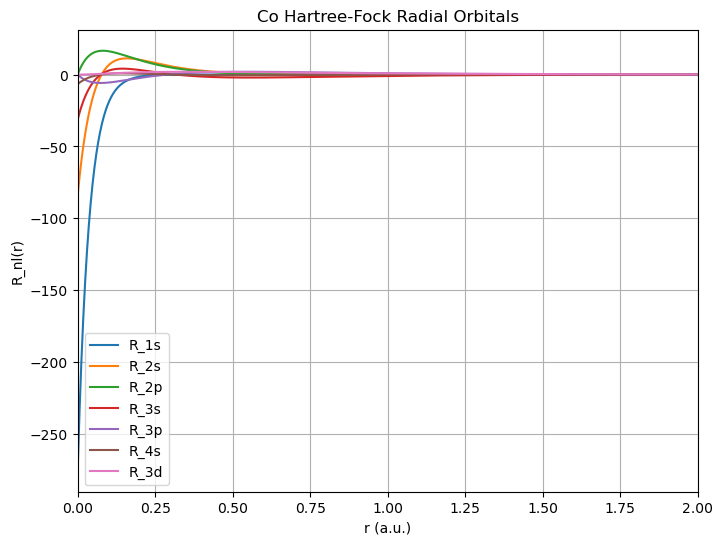

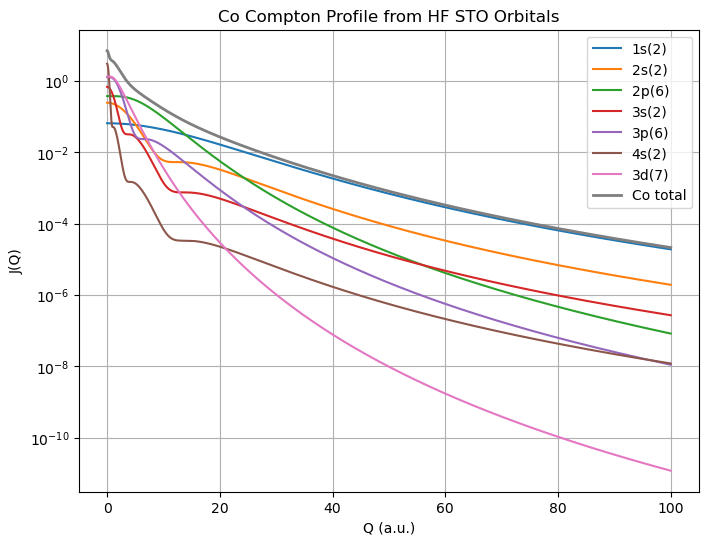

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Cobalt Hartree-Fock STO data
# Co: 1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(7) 4s(2)
# Ground term: 4s
# Source: Clementi & Roetti, At. Data Nucl. Data Tables 14, 177 (1974)
# Format: (n_j, Z_j, C_j)
# =====================================================

# =====================================================
# 1s orbital
# =====================================================

cobalt_1s = [
    (1, 26.83210, -0.961260),
    (1, 44.27070, -0.014190),
    (2, 22.93140, -0.030230),
    (2, 12.11360, -0.005460),
    (3, 11.31180,  0.003990),
    (3,  6.72828, -0.004440),
    (3,  5.58191,  0.003740),
    (4,  4.36115, -0.000680),
    (4,  2.15692,  0.000150),
    (4,  1.30768, -0.000100),
    (4,  0.86641,  0.000040),
]


# =====================================================
# 2s orbital
# =====================================================

cobalt_2s = [
    (1, 26.83210, -0.303960),
    (1, 44.27070,  0.000890),
    (2, 22.93140, -0.170980),
    (2, 12.11360,  0.880740),
    (3, 11.31180,  0.278560),
    (3,  6.72828,  0.056720),
    (3,  5.58191, -0.028380),
    (4,  4.36115,  0.004180),
    (4,  2.15692, -0.000640),
    (4,  1.30768,  0.000410),
    (4,  0.86641, -0.000160),
]


# =====================================================
# 3s orbital
# =====================================================

cobalt_3s = [
    (1, 26.83210, -0.114740),
    (1, 44.27070,  0.001050),
    (2, 22.93140, -0.064990),
    (2, 12.11360,  0.344170),
    (3, 11.31180,  0.259700),
    (3,  6.72828, -0.026900),
    (3,  5.58191, -0.841880),
    (4,  4.36115, -0.326350),
    (4,  2.15692, -0.008310),
    (4,  1.30768,  0.003090),
    (4,  0.86641, -0.001060),
]


# =====================================================
# 4s orbital
# =====================================================

cobalt_4s = [
    (1, 26.83210, -0.023950),
    (1, 44.27070,  0.000120),
    (2, 22.93140, -0.014250),
    (2, 12.11360,  0.074020),
    (3, 11.31180,  0.057050),
    (3,  6.72828,  0.019360),
    (3,  5.58191, -0.244600),
    (4,  4.36115, -0.047740),
    (4,  2.15692,  0.384420),
    (4,  1.30768,  0.572900),
    (4,  0.86641,  0.162520),
]


# =====================================================
# 2p orbital
# =====================================================

cobalt_2p = [
    (2, 11.15900,  0.864580),
    (2, 19.34770,  0.086180),
    (3,  8.62558,  0.082730),
    (3,  6.06638, -0.000140),
    (3,  3.93006, -0.000160),
    (3,  2.78815,  0.000710),
]


# =====================================================
# 3p orbital
# =====================================================

cobalt_3p = [
    (2, 11.15900, -0.339490),
    (2, 19.34770, -0.025270),
    (3,  8.62558, -0.104000),
    (3,  6.06638,  0.520010),
    (3,  3.93006,  0.541340),
    (3,  2.78815,  0.129720),
]


# =====================================================
# 3d orbital
# =====================================================

cobalt_3d = [
    (3,  13.3848,  0.017145),
    (3,   7.0420,  0.215033),
    (3,   4.2891,  0.412560),
    (3,   2.5511,  0.385376),
    (3,   1.5435,  0.135684),
]

# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapezoid(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Print STO radial formula
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")

# =====================================================
# Build Cobalt radial orbitals
# =====================================================

R1s = R_nl(r, cobalt_1s)
R2s = R_nl(r, cobalt_2s)
R3s = R_nl(r, cobalt_3s)
R4s = R_nl(r, cobalt_4s)

R2p = R_nl(r, cobalt_2p)
R3p = R_nl(r, cobalt_3p)

R3d = R_nl(r, cobalt_3d)


print_R_formula(cobalt_1s, "Co_R1s")
print_R_formula(cobalt_2s, "Co_R2s")
print_R_formula(cobalt_3s, "Co_R3s")
print_R_formula(cobalt_4s, "Co_R4s")
print_R_formula(cobalt_2p, "Co_R2p")
print_R_formula(cobalt_3p, "Co_R3p")
print_R_formula(cobalt_3d, "Co_R3d")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 3d =", np.trapezoid(I_3d, p))
print("Norm 4s =", np.trapezoid(I_4s, p))


# Cobalt has 1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(7) 4s(2)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 7*J_3d + 2*J_4s

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s(2)": J_1s,
    "J_2s(2)": J_2s,
    "J_2p(6)": J_2p,
    "J_3s(2)": J_3s,
    "J_3p(6)": J_3p,
    "J_3d(7)": J_3d,
    "J_4s(2)": J_4s,
    "J_total_Co": J_total
    })
print(table)
table.to_csv("Co_STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Co Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, 7*J_3d, label="3d(7)")
plt.plot(Q, J_total, label="Co total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Co Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()